# Bloom Filter Project

**Team Members:** Alejandrina Jimenez Guzman (2467951) and Joffre Sanchez ()

This notebook visualizes the benchmark results from the HPC run.

## Implementation

The Bloom Filter has been implemented as a class using an Object-Oriented approach.

### Main Attributes
- `bit_array`: List of booleans representing the filter
- `size` (m): Size of the bit array
- `num_hashes` (k): Number of hash functions
- `expected_elements` (n)
- `false_positive_rate` (p)

### Supported Operations
- `add(item)` / `insert(item)`
- `contains(item)` / `__contains__(item)`
- `add_many(items)`
- `get_info()`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.bloom_filter import BloomFilter   # Adjust path if needed

plt.style.use('default')
sns.set_palette("tab10")
%matplotlib inline

## Example of how to use this implementation

In [12]:
bf = BloomFilter(expected_elements=10000, false_positive_rate=0.01)

bf.add("apple")
bf.add("banana")
bf.add("python")

print("Contains 'apple'?", bf.contains("apple"))
print("Contains 'orange'?", "orange" in bf)
print("Contains 'ban'?", bf.contains("ban"))

print("\nBloom Filter Info:")
print(bf.get_info())

BloomFilter created -> bits: 95,851 | hashes: 7 | expected items: 10000 | target FP: 0.01
Contains 'apple'? True
Contains 'orange'? False
Contains 'ban'? False

Bloom Filter Info:
{'expected_elements': 10000, 'false_positive_rate': 0.01, 'bit_array_size': 95851, 'num_hash_functions': 7, 'bits_set': 21, 'fill_ratio': 0.0002}


## Testing

We tested the Bloom Filter for correctness using three different data types.

In [ ]:
from src.test_bloom import run_tests
run_tests()

=== Starting Bloom Filter Tests ===

1. Basic correctness test
BloomFilter created -> bits: 6,236 | hashes: 5 | expected items: 1000 | target FP: 0.05
All inserted items are detected

2. Testing with 3 different datasets (same filter parameters)
BloomFilter created -> bits: 479,253 | hashes: 7 | expected items: 50000 | target FP: 0.01
   Words dataset size: 6

   → Testing Natural Words
BloomFilter created -> bits: 479,253 | hashes: 7 | expected items: 50000 | target FP: 0.01
False Positive Rate: 0.0000  (0/2)
   Fill ratio: 0.0001

   → Testing Random Strings
BloomFilter created -> bits: 479,253 | hashes: 7 | expected items: 50000 | target FP: 0.01
False Positive Rate: 0.0032  (32/10000)
   Fill ratio: 0.4425

   → Testing DNA k-mers
BloomFilter created -> bits: 479,253 | hashes: 7 | expected items: 50000 | target FP: 0.01
False Positive Rate: 0.0036  (36/10000)
   Fill ratio: 0.4428

Dataset tests completed

3. False positive rate when exceeding capacity
BloomFilter created -> bits: 

#  Results & Plots


In [2]:
# Load benchmark results
df_natural = pd.read_csv('benchmark_natural_words.csv')
df_random = pd.read_csv('benchmark_random_strings.csv')
df_dna = pd.read_csv('benchmark_dna_kmers.csv')

# Load analysis results
df_fp = pd.read_csv('fp_rate_analysis.csv')
df_comp = pd.read_csv('compression_analysis.csv')

print("All files loaded successfully!")
print(f"Natural Words: {len(df_natural)} sizes")
print(f"False Positive Analysis: {len(df_fp)} points")

All files loaded successfully!
Natural Words: 5 sizes
False Positive Analysis: 7 points


### Performance Plots

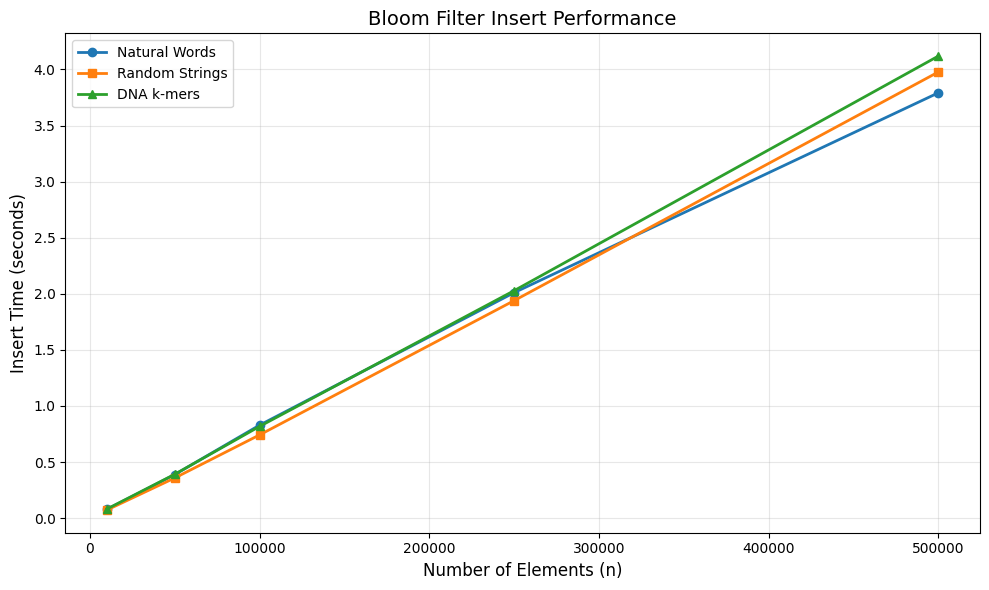

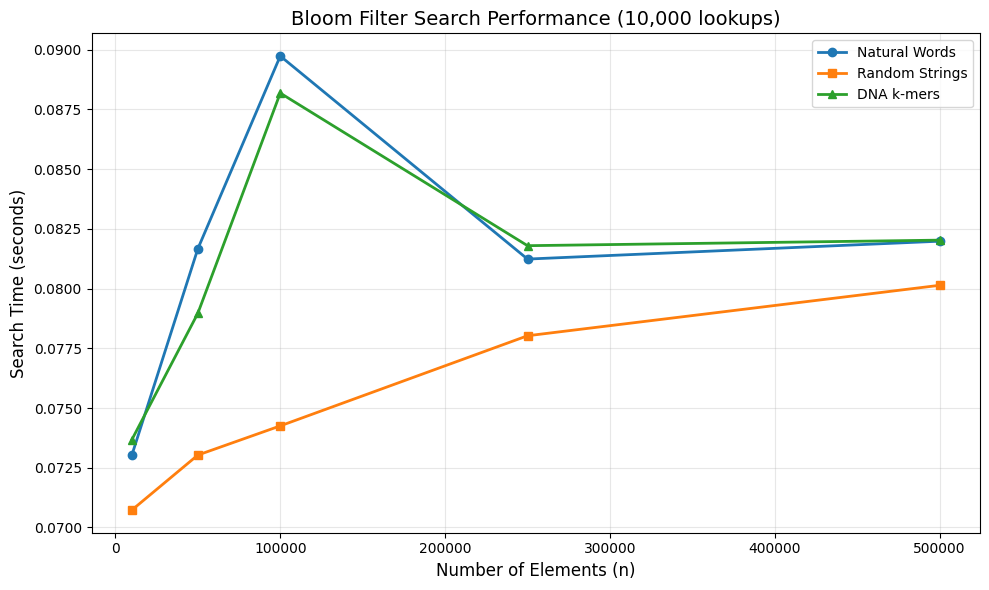

In [3]:
# TIME PLOT
plt.figure(figsize=(10, 6))

plt.plot(df_natural['num_elements'], df_natural['insert_time_sec'], 'o-',
         label='Natural Words', linewidth=2)
plt.plot(df_random['num_elements'], df_random['insert_time_sec'], 's-',
         label='Random Strings', linewidth=2)
plt.plot(df_dna['num_elements'], df_dna['insert_time_sec'], '^-',
         label='DNA k-mers', linewidth=2)

plt.xlabel('Number of Elements (n)', fontsize=12)
plt.ylabel('Insert Time (seconds)', fontsize=12)
plt.title('Bloom Filter Insert Performance', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SEARCH TIME PLOT
plt.figure(figsize=(10, 6))

plt.plot(df_natural['num_elements'], df_natural['search_time_sec'], 'o-',
         label='Natural Words', linewidth=2)
plt.plot(df_random['num_elements'], df_random['search_time_sec'], 's-',
         label='Random Strings', linewidth=2)
plt.plot(df_dna['num_elements'], df_dna['search_time_sec'], '^-',
         label='DNA k-mers', linewidth=2)

plt.xlabel('Number of Elements (n)', fontsize=12)
plt.ylabel('Search Time (seconds)', fontsize=12)
plt.title('Bloom Filter Search Performance (10,000 lookups)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### False Positive Rate Plot

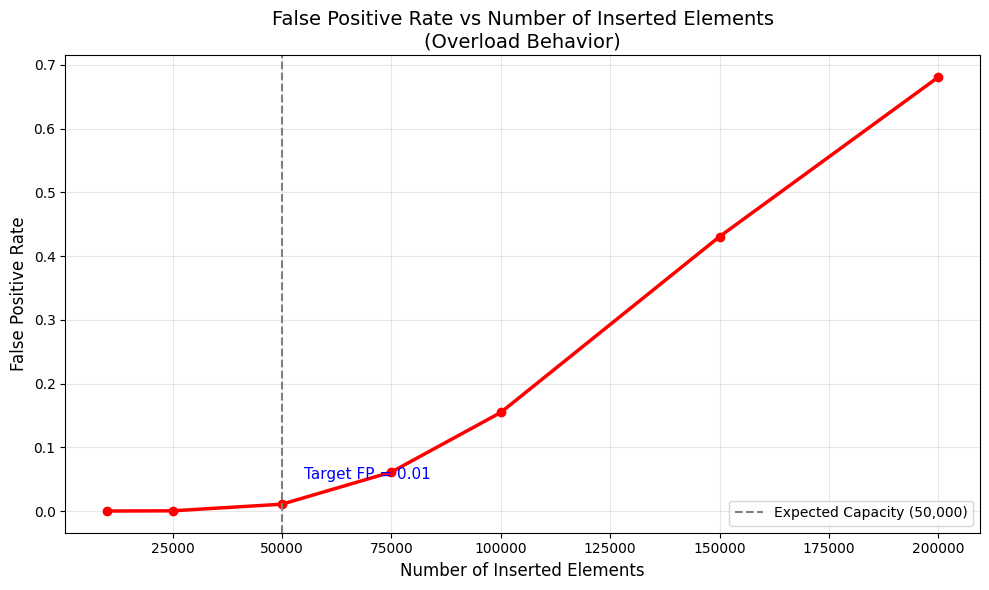

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df_fp['inserted'], df_fp['fp_rate'], 'o-', color='red',
         linewidth=2.5, markersize=6)
plt.axvline(x=50000, color='gray', linestyle='--',
            label='Expected Capacity (50,000)')

plt.xlabel('Number of Inserted Elements', fontsize=12)
plt.ylabel('False Positive Rate', fontsize=12)
plt.title('False Positive Rate vs Number of Inserted Elements\n(Overload Behavior)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add text annotation
plt.text(55000, 0.05, 'Target FP = 0.01', fontsize=11, color='blue')

plt.tight_layout()
plt.show()

### Compression Rate Analysis

<Figure size 1000x600 with 0 Axes>

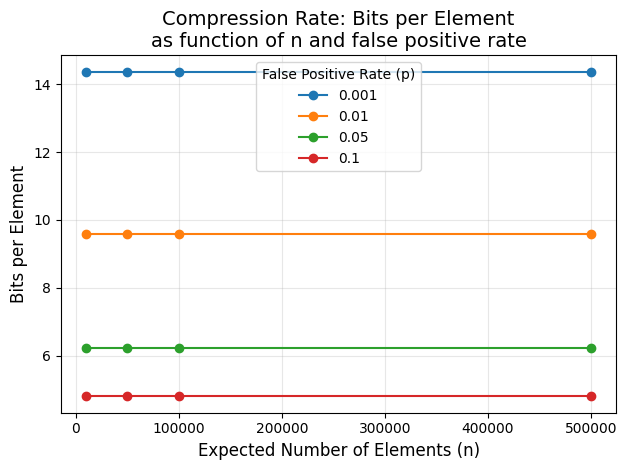


Compression Rate Summary:
    expected_n  false_positive_rate  bits_per_element
0        10000                 0.00             14.38
1        10000                 0.01              9.59
2        10000                 0.05              6.24
3        10000                 0.10              4.79
4        50000                 0.00             14.38
5        50000                 0.01              9.59
6        50000                 0.05              6.24
7        50000                 0.10              4.79
8       100000                 0.00             14.38
9       100000                 0.01              9.59
10      100000                 0.05              6.24
11      100000                 0.10              4.79
12      500000                 0.00             14.38
13      500000                 0.01              9.59
14      500000                 0.05              6.24
15      500000                 0.10              4.79


In [5]:
comp_pivot = df_comp.pivot(index='expected_n', columns='false_positive_rate',
                           values='bits_per_element')

plt.figure(figsize=(10, 6))
comp_pivot.plot(marker='o')
plt.xlabel('Expected Number of Elements (n)', fontsize=12)
plt.ylabel('Bits per Element', fontsize=12)
plt.title('Compression Rate: Bits per Element\nas function of n and false positive rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='False Positive Rate (p)')
plt.tight_layout()
plt.show()

print("\nCompression Rate Summary:")
print(df_comp[['expected_n', 'false_positive_rate', 'bits_per_element']].round(2))


## Conclusions

- The Bloom Filter achieves near **constant time** O(k) for both insert and search operations, as confirmed by the flat performance curves.
- The **false positive rate** stays close to the target (0.01) when the number of elements is within the expected capacity, then increases significantly when overloaded.
- Good **compression rate** (≈ 9.6 bits per element for p=0.01).
- Hash functions perform similarly across natural language, random strings, and DNA data.
- All assignment requirements have been fulfilled..
- Different datasets show very similar performance behavior.

All requirements of the assignment are fulfilled.